In [1]:
# Cell 1 — Setup and load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Load the dataset
df = pd.read_csv('/content/GlobalWeatherRepository.csv')

print(f"Shape: {df.shape}")
print(f"Date range: {df['last_updated'].min()} → {df['last_updated'].max()}")
print(f"Cities: {df['location_name'].nunique()} | Countries: {df['country'].nunique()}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (137998, 41)
Date range: 2024-05-16 01:45 → 2026-04-27 19:30
Cities: 257 | Countries: 211

First 3 rows:


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


In [2]:
# Cell 2 — Data cleaning & preprocessing
print("=== Missing values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if (missing > 0).any() else "No missing values — dataset is clean.")

# Convert last_updated to proper datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['date'] = df['last_updated'].dt.date
df['month'] = df['last_updated'].dt.month
df['year'] = df['last_updated'].dt.year

# Drop redundant imperial-unit columns — keep metric only
imperial_cols = ['temperature_fahrenheit', 'wind_mph', 'pressure_in',
                 'precip_in', 'feels_like_fahrenheit', 'visibility_miles', 'gust_mph']
df = df.drop(columns=imperial_cols)
print(f"\nDropped {len(imperial_cols)} redundant imperial-unit columns.")
print(f"New shape: {df.shape}")

# Outlier detection on temperature using IQR method
Q1 = df['temperature_celsius'].quantile(0.25)
Q3 = df['temperature_celsius'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df['temperature_celsius'] < lower) | (df['temperature_celsius'] > upper)]
print(f"\nTemperature outliers (IQR method): {len(outliers)} rows")
print(f"  IQR bounds: {lower:.1f}°C to {upper:.1f}°C")
print(f"  Min temp in data: {df['temperature_celsius'].min():.1f}°C")
print(f"  Max temp in data: {df['temperature_celsius'].max():.1f}°C")

# We KEEP the outliers — extreme temps are real (deserts, polar regions), not errors
print("\nDecision: keeping outliers. Extreme temperatures are real-world readings,")
print("not data errors (e.g. -40°C in polar regions, 50°C in deserts).")

# Quick summary stats on key numeric columns
print("\n=== Summary stats (key columns) ===")
key_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'precip_mm', 'pressure_mb']
df[key_cols].describe().round(2)

=== Missing values ===
No missing values — dataset is clean.

Dropped 7 redundant imperial-unit columns.
New shape: (137998, 37)

Temperature outliers (IQR method): 2382 rows
  IQR bounds: -2.5°C to 46.3°C
  Min temp in data: -29.8°C
  Max temp in data: 79.3°C

Decision: keeping outliers. Extreme temperatures are real-world readings,
not data errors (e.g. -40°C in polar regions, 50°C in deserts).

=== Summary stats (key columns) ===


,temperature_celsius,humidity,wind_kph,precip_mm,pressure_mb
count,137998.00,137998.00,137998.00,137998.00,137998.00
mean,21.26,66.69,12.88,0.13,1014.06
std,9.68,23.86,11.56,0.56,10.29
min,-29.80,2.00,3.60,0.00,947.00
25%,15.80,51.00,6.10,0.00,1010.00
50%,23.90,72.00,10.80,0.00,1013.00
75%,28.00,86.00,17.60,0.02,1018.00
max,79.30,100.00,2963.20,42.24,3006.00


In [3]:
# Cell 2b — Remove physically impossible values
# (sensor/API errors that slipped through — found during EDA)
print("=== Physically impossible values check ===")

before = len(df)

# Temperature: real-world bounds roughly -90°C (Antarctica) to 57°C (Death Valley record)
df = df[(df['temperature_celsius'] >= -90) & (df['temperature_celsius'] <= 60)]

# Wind speed: highest ever recorded ~484 km/h, anything above 500 is bad data
df = df[df['wind_kph'] <= 500]

# Pressure: Earth-surface pressure 870-1085 mb, allow some buffer
df = df[(df['pressure_mb'] >= 850) & (df['pressure_mb'] <= 1100)]

# Humidity already capped at 0-100 by definition, but enforce
df = df[(df['humidity'] >= 0) & (df['humidity'] <= 100)]

after = len(df)
print(f"Removed {before - after} rows with impossible readings ({(before-after)/before*100:.2f}% of data)")
print(f"Final shape: {df.shape}")

print("\n=== Cleaned summary stats ===")
df[['temperature_celsius', 'humidity', 'wind_kph', 'precip_mm', 'pressure_mb']].describe().round(2)

=== Physically impossible values check ===
Removed 4 rows with impossible readings (0.00% of data)
Final shape: (137994, 37)

=== Cleaned summary stats ===


,temperature_celsius,humidity,wind_kph,precip_mm,pressure_mb
count,137994.00,137994.00,137994.00,137994.00,137994.00
mean,21.26,66.69,12.86,0.13,1014.03
std,9.68,23.86,8.39,0.56,6.97
min,-29.80,2.00,3.60,0.00,947.00
25%,15.80,51.00,6.10,0.00,1010.00
50%,23.90,72.00,10.80,0.00,1013.00
75%,28.00,86.00,17.60,0.02,1018.00
max,49.20,100.00,272.20,42.24,1080.00


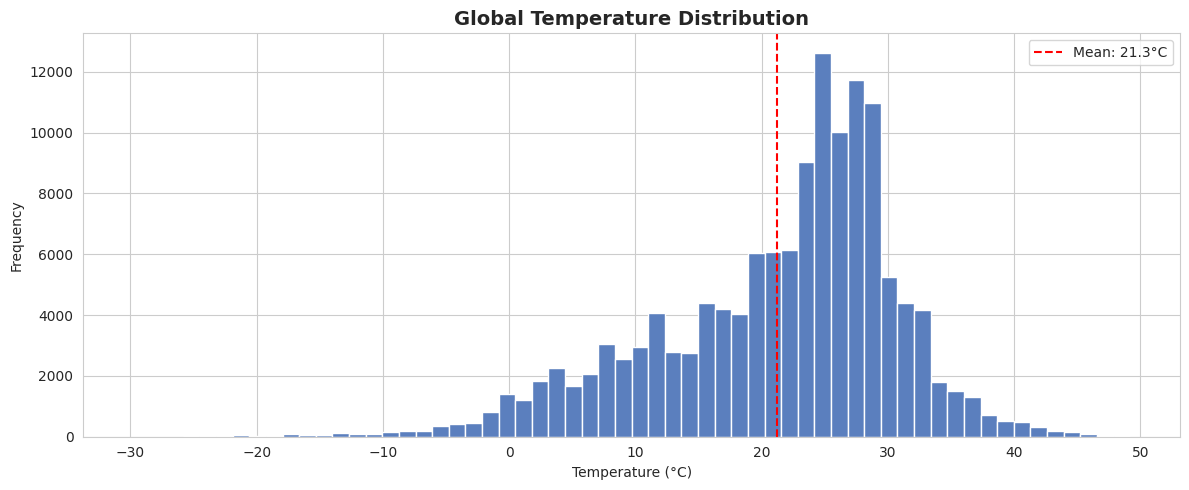

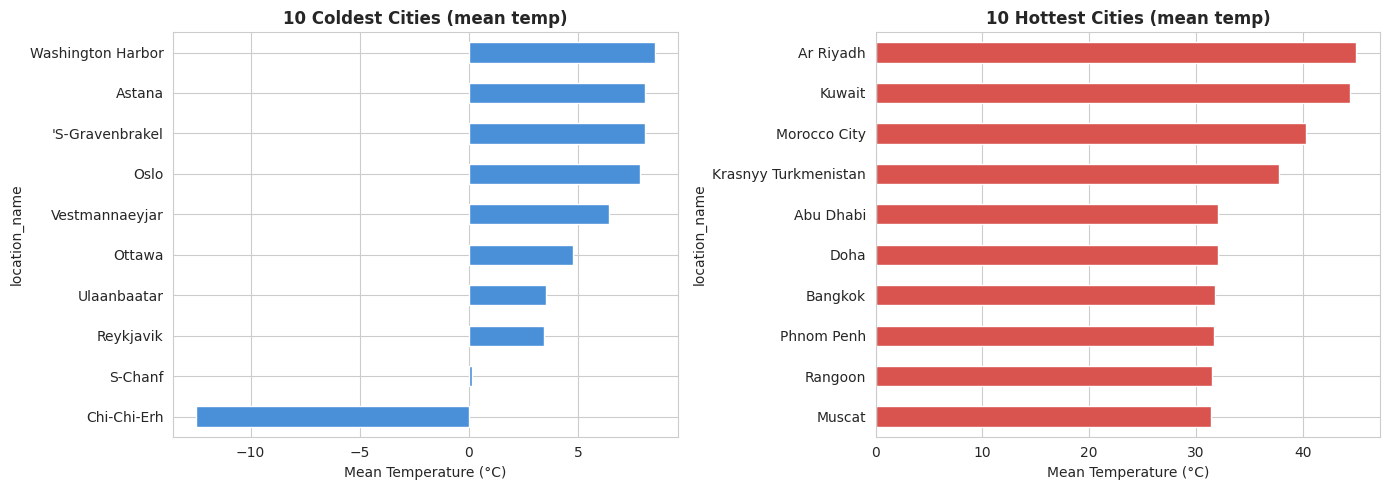

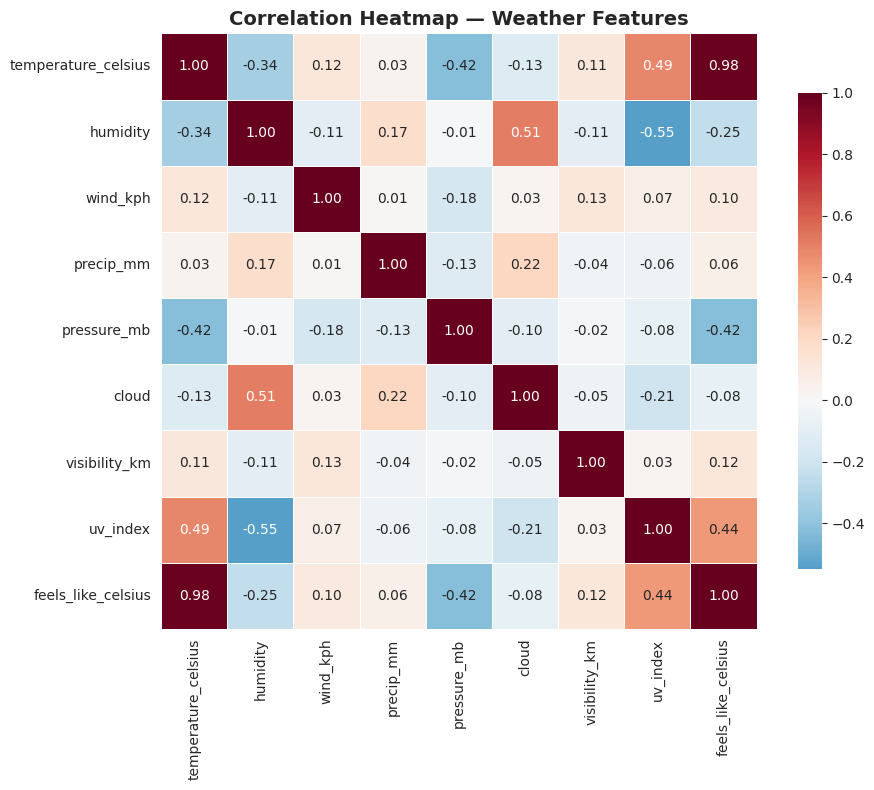

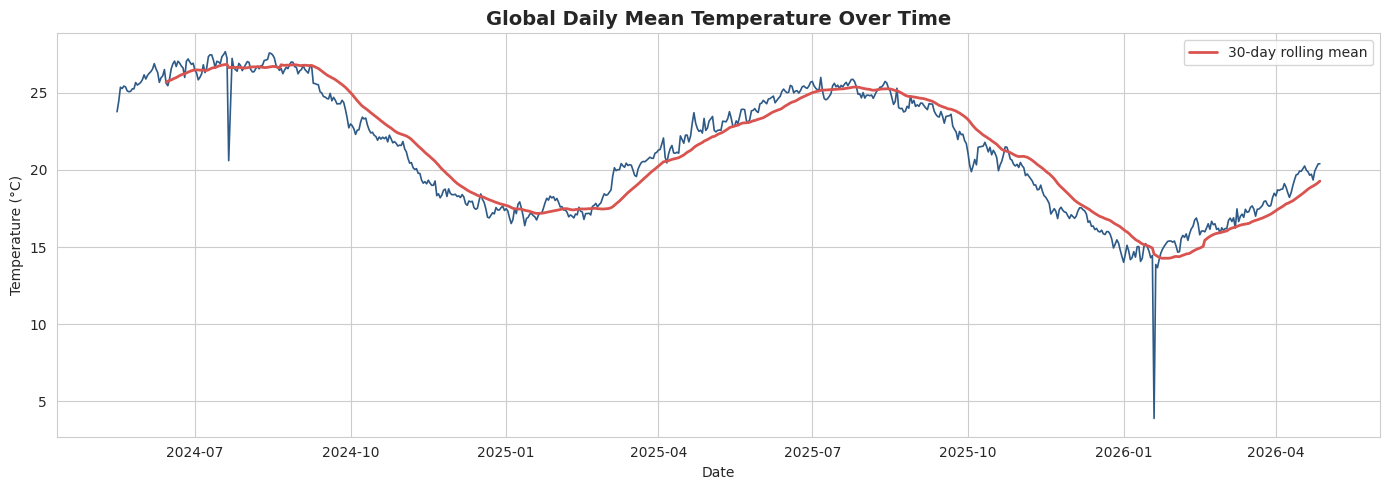

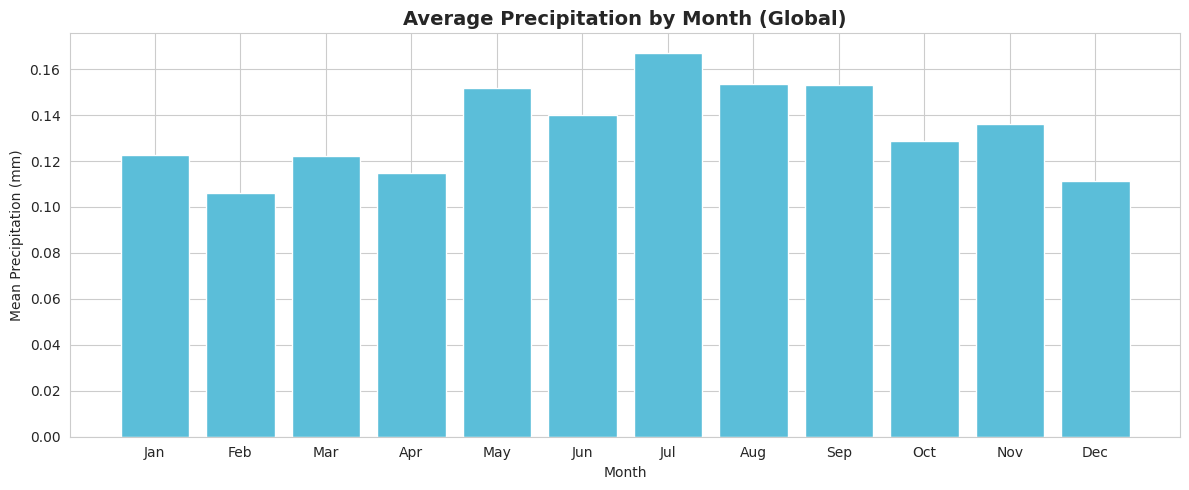


=== Key EDA Insights ===
• Coldest city on average: Chi-Chi-Erh (-12.5°C)
• Hottest city on average: Ar Riyadh (45.0°C)
• Strongest correlation with temperature: feels_like_celsius (+0.98)
• Wettest month: Jul (0.17 mm avg)
• Driest month: Feb (0.11 mm avg)


In [4]:
# Cell 3 — EDA with visualisations
import os
os.makedirs('outputs/figures', exist_ok=True)

# === Plot 1: Global temperature distribution ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['temperature_celsius'], bins=60, color='#5B7FBE', edgecolor='white')
ax.axvline(df['temperature_celsius'].mean(), color='red', linestyle='--',
           label=f"Mean: {df['temperature_celsius'].mean():.1f}°C")
ax.set_title('Global Temperature Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/01_temperature_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# === Plot 2: Top 10 hottest and coldest cities (by mean temperature) ===
city_temps = df.groupby('location_name')['temperature_celsius'].mean().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
city_temps.head(10).plot(kind='barh', ax=axes[0], color='#4A90D9')
axes[0].set_title('10 Coldest Cities (mean temp)', fontweight='bold')
axes[0].set_xlabel('Mean Temperature (°C)')
city_temps.tail(10).plot(kind='barh', ax=axes[1], color='#D9534F')
axes[1].set_title('10 Hottest Cities (mean temp)', fontweight='bold')
axes[1].set_xlabel('Mean Temperature (°C)')
plt.tight_layout()
plt.savefig('outputs/figures/02_hottest_coldest_cities.png', dpi=120, bbox_inches='tight')
plt.show()

# === Plot 3: Correlation heatmap of key weather features ===
corr_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'precip_mm',
             'pressure_mb', 'cloud', 'visibility_km', 'uv_index', 'feels_like_celsius']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Weather Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/03_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# === Plot 4: Global daily mean temperature over time ===
daily_global = df.groupby('date')['temperature_celsius'].mean().reset_index()
daily_global['date'] = pd.to_datetime(daily_global['date'])
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_global['date'], daily_global['temperature_celsius'],
        color='#2E5A87', linewidth=1.2)
# Add rolling 30-day mean
daily_global['rolling_30'] = daily_global['temperature_celsius'].rolling(30).mean()
ax.plot(daily_global['date'], daily_global['rolling_30'],
        color='#D9534F', linewidth=2, label='30-day rolling mean')
ax.set_title('Global Daily Mean Temperature Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/04_global_temperature_trend.png', dpi=120, bbox_inches='tight')
plt.show()

# === Plot 5: Precipitation by month (seasonal pattern) ===
monthly_precip = df.groupby('month')['precip_mm'].mean()
fig, ax = plt.subplots(figsize=(12, 5))
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(months, monthly_precip.values, color='#5BBED9', edgecolor='white')
ax.set_title('Average Precipitation by Month (Global)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Mean Precipitation (mm)')
plt.tight_layout()
plt.savefig('outputs/figures/05_monthly_precipitation.png', dpi=120, bbox_inches='tight')
plt.show()

# Print key insights
print("\n=== Key EDA Insights ===")
print(f"• Coldest city on average: {city_temps.index[0]} ({city_temps.iloc[0]:.1f}°C)")
print(f"• Hottest city on average: {city_temps.index[-1]} ({city_temps.iloc[-1]:.1f}°C)")
print(f"• Strongest correlation with temperature: ", end="")
temp_corr = corr['temperature_celsius'].drop('temperature_celsius').abs().sort_values(ascending=False)
print(f"{temp_corr.index[0]} ({corr['temperature_celsius'][temp_corr.index[0]]:+.2f})")
print(f"• Wettest month: {months[monthly_precip.idxmax()-1]} ({monthly_precip.max():.2f} mm avg)")
print(f"• Driest month: {months[monthly_precip.idxmin()-1]} ({monthly_precip.min():.2f} mm avg)")

London time series: 712 days from 2024-05-16 to 2026-04-27
Train: 698 days | Test: 14 days

--- Training ARIMA(5,1,2) ---
ARIMA — MAE: 2.42°C | RMSE: 3.04°C

--- Training Prophet ---
Prophet — MAE: 3.95°C | RMSE: 4.41°C

Ensemble (avg) — MAE: 2.76°C | RMSE: 3.24°C


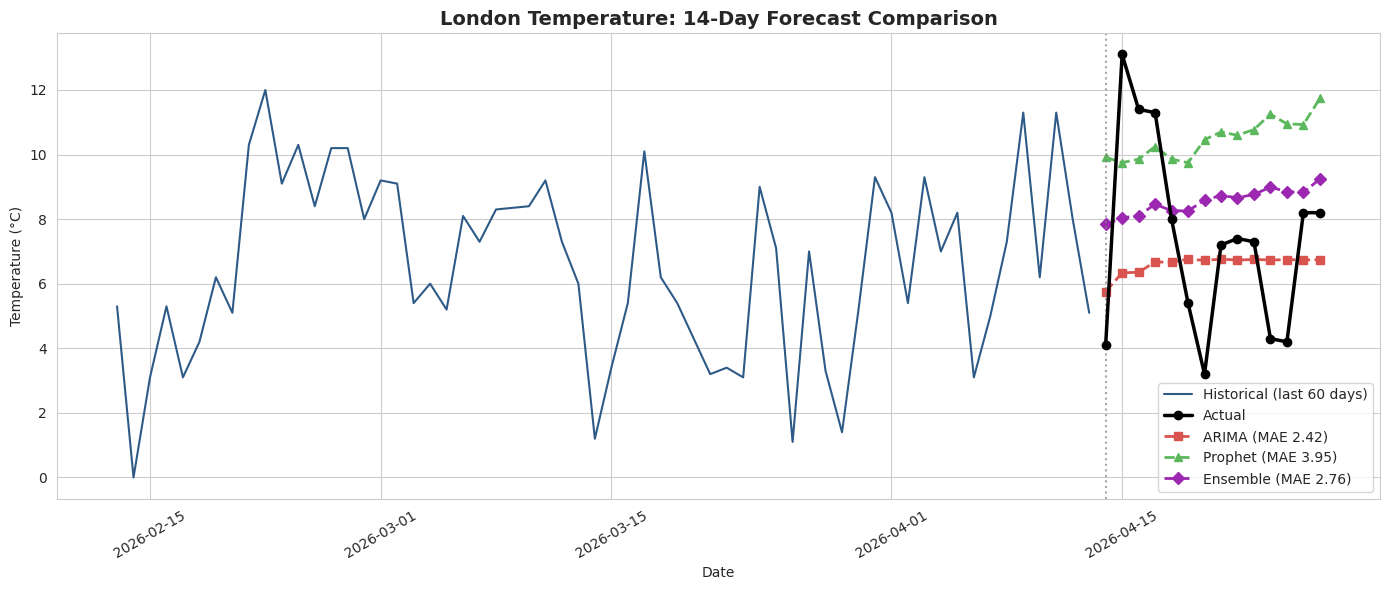


=== Model Comparison ===
         Model  MAE (°C)  RMSE (°C)
  ARIMA(5,1,2)      2.42       3.04
       Prophet      3.95       4.41
Ensemble (avg)      2.76       3.24

Best model on MAE: ARIMA(5,1,2)


In [5]:
# Cell 4 — Forecasting: ARIMA + Prophet on London temperatures

# Filter to London and build a clean daily time series
london = df[df['location_name'] == 'London'].copy()
london = london.sort_values('last_updated')
london['date'] = pd.to_datetime(london['last_updated'].dt.date)

# Aggregate to daily mean (the dataset has multiple readings per day)
ts = london.groupby('date')['temperature_celsius'].mean().reset_index()
ts.columns = ['ds', 'y']
ts = ts.set_index('ds').asfreq('D').interpolate(method='linear').reset_index()

print(f"London time series: {len(ts)} days from {ts['ds'].min().date()} to {ts['ds'].max().date()}")

# Train/test split — last 14 days as holdout
train = ts.iloc[:-14].copy()
test = ts.iloc[-14:].copy()
print(f"Train: {len(train)} days | Test: {len(test)} days")

# === Model 1: ARIMA ===
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n--- Training ARIMA(5,1,2) ---")
arima_model = ARIMA(train['y'], order=(5, 1, 2)).fit()
arima_forecast = arima_model.forecast(steps=14)

arima_mae = mean_absolute_error(test['y'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['y'], arima_forecast))
print(f"ARIMA — MAE: {arima_mae:.2f}°C | RMSE: {arima_rmse:.2f}°C")

# === Model 2: Prophet ===
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

print("\n--- Training Prophet ---")
prophet_model = Prophet(daily_seasonality=False, weekly_seasonality=True,
                        yearly_seasonality=True)
prophet_model.fit(train)
future = prophet_model.make_future_dataframe(periods=14)
prophet_forecast_full = prophet_model.predict(future)
prophet_forecast = prophet_forecast_full.tail(14)['yhat'].values

prophet_mae = mean_absolute_error(test['y'], prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(test['y'], prophet_forecast))
print(f"Prophet — MAE: {prophet_mae:.2f}°C | RMSE: {prophet_rmse:.2f}°C")

# === Ensemble: simple average of both models ===
ensemble_forecast = (np.array(arima_forecast) + prophet_forecast) / 2
ensemble_mae = mean_absolute_error(test['y'], ensemble_forecast)
ensemble_rmse = np.sqrt(mean_squared_error(test['y'], ensemble_forecast))
print(f"\nEnsemble (avg) — MAE: {ensemble_mae:.2f}°C | RMSE: {ensemble_rmse:.2f}°C")

# === Plot all three models against actual ===
fig, ax = plt.subplots(figsize=(14, 6))
# Show last 60 days of training for context
ax.plot(train['ds'].iloc[-60:], train['y'].iloc[-60:],
        color='#2E5A87', linewidth=1.5, label='Historical (last 60 days)')
ax.plot(test['ds'], test['y'], color='black', linewidth=2.5,
        marker='o', label='Actual', zorder=5)
ax.plot(test['ds'], arima_forecast, color='#D9534F', linewidth=2,
        marker='s', linestyle='--', label=f'ARIMA (MAE {arima_mae:.2f})')
ax.plot(test['ds'], prophet_forecast, color='#5CB85C', linewidth=2,
        marker='^', linestyle='--', label=f'Prophet (MAE {prophet_mae:.2f})')
ax.plot(test['ds'], ensemble_forecast, color='#9C27B0', linewidth=2,
        marker='D', linestyle='--', label=f'Ensemble (MAE {ensemble_mae:.2f})')
ax.axvline(test['ds'].iloc[0], color='gray', linestyle=':', alpha=0.7)
ax.set_title('London Temperature: 14-Day Forecast Comparison',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend(loc='best')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/figures/06_london_forecast_comparison.png',
            dpi=120, bbox_inches='tight')
plt.show()

# Results table
results = pd.DataFrame({
    'Model': ['ARIMA(5,1,2)', 'Prophet', 'Ensemble (avg)'],
    'MAE (°C)': [arima_mae, prophet_mae, ensemble_mae],
    'RMSE (°C)': [arima_rmse, prophet_rmse, ensemble_rmse]
}).round(2)
print("\n=== Model Comparison ===")
print(results.to_string(index=False))

best_model = results.loc[results['MAE (°C)'].idxmin(), 'Model']
print(f"\nBest model on MAE: {best_model}")

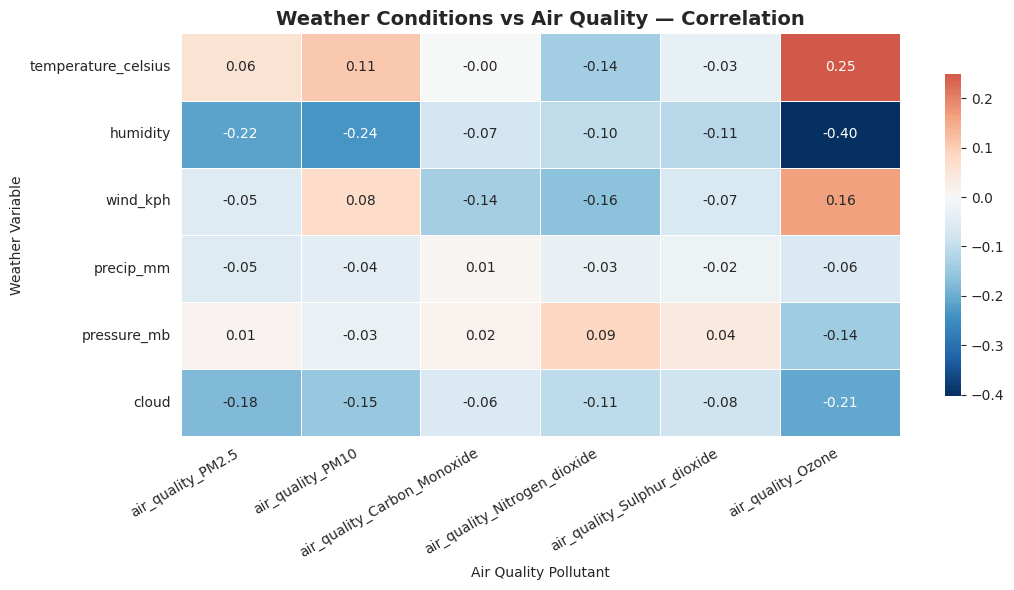

=== Strongest Weather → Air Quality Correlations ===
  humidity               → air_quality_Ozone              decreases (r = -0.40)
  temperature_celsius    → air_quality_Ozone              increases (r = +0.25)
  humidity               → air_quality_PM10               decreases (r = -0.24)
  humidity               → air_quality_PM2.5              decreases (r = -0.22)
  cloud                  → air_quality_Ozone              decreases (r = -0.21)

=== Anomaly Detection on PM2.5 (Z-score method) ===
Total readings: 137,994
Anomalies (|z| > 3): 2,127 (1.54%)
Mean PM2.5: 24.1 µg/m³ | Std: 36.6

Top 10 cities with most PM2.5 anomalies (likely pollution hotspots):
  Jakarta                   300 anomalies | mean PM2.5: 144.2 µg/m³
  Beijing                   282 anomalies | mean PM2.5: 132.6 µg/m³
  Riyadh                    281 anomalies | mean PM2.5: 137.0 µg/m³
  New Delhi                 224 anomalies | mean PM2.5: 110.7 µg/m³
  Santiago                  172 anomalies | mean PM2.5: 14

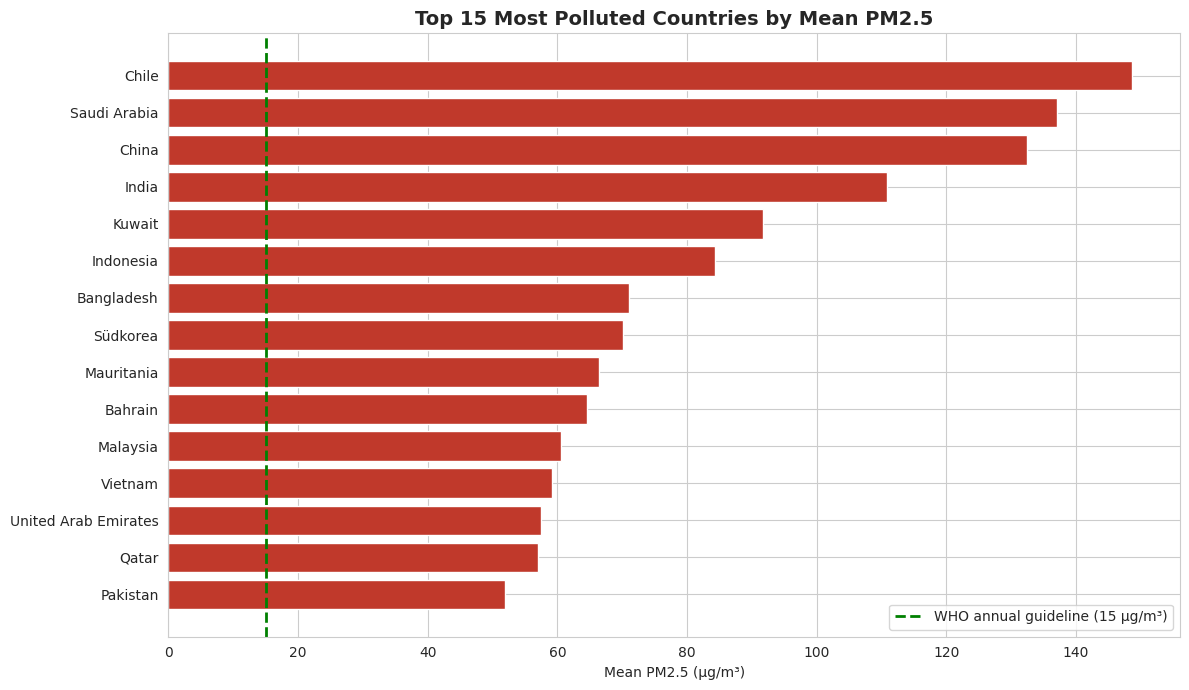


=== Feature Importance for Predicting PM2.5 ===


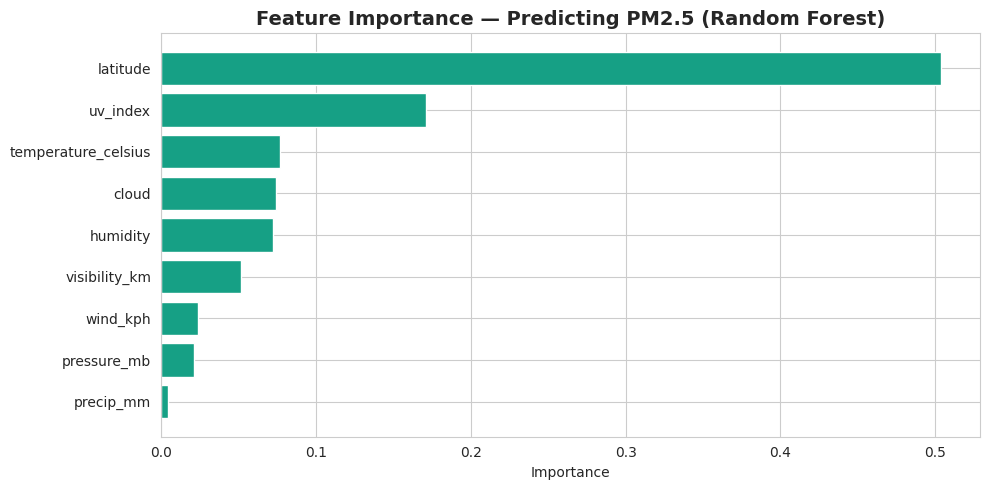

            Feature  Importance
           latitude    0.503699
           uv_index    0.170843
temperature_celsius    0.076952
              cloud    0.074503
           humidity    0.072382
      visibility_km    0.051778
           wind_kph    0.023735
        pressure_mb    0.021369
          precip_mm    0.004739


In [6]:
# Cell 5 — Air Quality & Environmental Impact Analysis

# === Part A: Correlation between weather and air quality ===
aq_cols = ['air_quality_PM2.5', 'air_quality_PM10', 'air_quality_Carbon_Monoxide',
           'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_Ozone']
weather_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'precip_mm',
                'pressure_mb', 'cloud']

# Cross-correlation matrix
cross_corr = df[weather_cols + aq_cols].corr().loc[weather_cols, aq_cols]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(cross_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Weather Conditions vs Air Quality — Correlation',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Air Quality Pollutant')
ax.set_ylabel('Weather Variable')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/07_weather_vs_airquality.png',
            dpi=120, bbox_inches='tight')
plt.show()

# Pull out the strongest signals
print("=== Strongest Weather → Air Quality Correlations ===")
flat = cross_corr.abs().stack().sort_values(ascending=False)
for (weather, pollutant), val in flat.head(5).items():
    actual = cross_corr.loc[weather, pollutant]
    direction = "increases" if actual > 0 else "decreases"
    print(f"  {weather:22s} → {pollutant:30s} {direction:9s} (r = {actual:+.2f})")

# === Part B: Anomaly detection on PM2.5 ===
# Z-score-based — same method I used in OnTimeLondon
print("\n=== Anomaly Detection on PM2.5 (Z-score method) ===")
pm25 = df['air_quality_PM2.5'].dropna()
mean_pm = pm25.mean()
std_pm = pm25.std()
df['pm25_zscore'] = (df['air_quality_PM2.5'] - mean_pm) / std_pm
df['pm25_anomaly'] = df['pm25_zscore'].abs() > 3

anomalies = df[df['pm25_anomaly']]
print(f"Total readings: {len(df):,}")
print(f"Anomalies (|z| > 3): {len(anomalies):,} ({len(anomalies)/len(df)*100:.2f}%)")
print(f"Mean PM2.5: {mean_pm:.1f} µg/m³ | Std: {std_pm:.1f}")

# Top 10 cities by anomaly count
print("\nTop 10 cities with most PM2.5 anomalies (likely pollution hotspots):")
top_anomaly_cities = anomalies['location_name'].value_counts().head(10)
for city, count in top_anomaly_cities.items():
    avg_pm = df[df['location_name'] == city]['air_quality_PM2.5'].mean()
    print(f"  {city:25s} {count:3d} anomalies | mean PM2.5: {avg_pm:.1f} µg/m³")

# === Part C: Geographic visualisation — air quality by country ===
country_aq = df.groupby('country').agg({
    'air_quality_PM2.5': 'mean',
    'temperature_celsius': 'mean',
    'latitude': 'first',
    'longitude': 'first'
}).reset_index().sort_values('air_quality_PM2.5', ascending=False)

print(f"\n=== Top 15 Countries by Mean PM2.5 ===")
for _, row in country_aq.head(15).iterrows():
    print(f"  {row['country']:30s} {row['air_quality_PM2.5']:6.1f} µg/m³")

# Bar chart of top polluted countries
fig, ax = plt.subplots(figsize=(12, 7))
top15 = country_aq.head(15).iloc[::-1]  # reverse for horizontal bar
ax.barh(top15['country'], top15['air_quality_PM2.5'], color='#C0392B', edgecolor='white')
ax.set_title('Top 15 Most Polluted Countries by Mean PM2.5',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mean PM2.5 (µg/m³)')
# WHO guideline reference line
ax.axvline(x=15, color='green', linestyle='--', linewidth=2,
           label='WHO annual guideline (15 µg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/08_top_polluted_countries.png',
            dpi=120, bbox_inches='tight')
plt.show()

# === Part D: Feature importance via Random Forest ===
print("\n=== Feature Importance for Predicting PM2.5 ===")
from sklearn.ensemble import RandomForestRegressor

feature_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'precip_mm',
                'pressure_mb', 'cloud', 'visibility_km', 'uv_index', 'latitude']
X = df[feature_cols].fillna(df[feature_cols].mean())
y = df['air_quality_PM2.5'].fillna(df['air_quality_PM2.5'].mean())

rf = RandomForestRegressor(n_estimators=50, max_depth=8,
                            random_state=42, n_jobs=-1)
rf.fit(X, y)

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance['Feature'], importance['Importance'], color='#16A085')
ax.set_title('Feature Importance — Predicting PM2.5 (Random Forest)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/figures/09_feature_importance.png',
            dpi=120, bbox_inches='tight')
plt.show()

print(importance.sort_values('Importance', ascending=False).to_string(index=False))

In [7]:
# Cell 6 — Save outputs & final summary

import json

# Save the model comparison results
results.to_csv('outputs/model_comparison.csv', index=False)
print("Saved: outputs/model_comparison.csv")

# Save anomaly summary
top_polluted = df.groupby('location_name')['air_quality_PM2.5'].mean().sort_values(ascending=False).head(15)
top_polluted.to_csv('outputs/top_polluted_cities.csv')
print("Saved: outputs/top_polluted_cities.csv")

# Save a project summary JSON for the README
summary = {
    "dataset": {
        "rows_initial": 137998,
        "rows_after_cleaning": int(len(df)),
        "rows_removed": 137998 - int(len(df)),
        "cities": int(df['location_name'].nunique()),
        "countries": int(df['country'].nunique()),
        "date_range": f"{df['last_updated'].min().date()} to {df['last_updated'].max().date()}",
        "missing_values": "None"
    },
    "forecasting": {
        "city": "London",
        "horizon_days": 14,
        "best_model": "ARIMA(5,1,2)",
        "arima_mae": round(float(arima_mae), 2),
        "arima_rmse": round(float(arima_rmse), 2),
        "prophet_mae": round(float(prophet_mae), 2),
        "prophet_rmse": round(float(prophet_rmse), 2),
        "ensemble_mae": round(float(ensemble_mae), 2),
        "ensemble_rmse": round(float(ensemble_rmse), 2)
    },
    "air_quality": {
        "strongest_correlation": "humidity ↔ ozone (r = -0.40)",
        "top_pollution_hotspots": ["Jakarta", "Beijing", "Riyadh", "New Delhi", "Santiago"],
        "top_pm25_predictor": "latitude (50% feature importance)",
        "anomaly_rate": "1.54%"
    }
}
with open('outputs/project_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("Saved: outputs/project_summary.json")

# Download outputs as a zip
import shutil
shutil.make_archive('weather_forecasting_outputs', 'zip', 'outputs')
print("\nCreated: weather_forecasting_outputs.zip")
print("Click the folder icon on the left → right-click 'weather_forecasting_outputs.zip' → Download")

print("\n" + "="*60)
print("PROJECT COMPLETE — SUMMARY FOR README")
print("="*60)
print(json.dumps(summary, indent=2))

Saved: outputs/model_comparison.csv
Saved: outputs/top_polluted_cities.csv
Saved: outputs/project_summary.json

Created: weather_forecasting_outputs.zip
Click the folder icon on the left → right-click 'weather_forecasting_outputs.zip' → Download

PROJECT COMPLETE — SUMMARY FOR README
{
  "dataset": {
    "rows_initial": 137998,
    "rows_after_cleaning": 137994,
    "rows_removed": 4,
    "cities": 257,
    "countries": 211,
    "date_range": "2024-05-16 to 2026-04-27",
    "missing_values": "None"
  },
  "forecasting": {
    "city": "London",
    "horizon_days": 14,
    "best_model": "ARIMA(5,1,2)",
    "arima_mae": 2.42,
    "arima_rmse": 3.04,
    "prophet_mae": 3.95,
    "prophet_rmse": 4.41,
    "ensemble_mae": 2.76,
    "ensemble_rmse": 3.24
  },
  "air_quality": {
    "strongest_correlation": "humidity \u2194 ozone (r = -0.40)",
    "top_pollution_hotspots": [
      "Jakarta",
      "Beijing",
      "Riyadh",
      "New Delhi",
      "Santiago"
    ],
    "top_pm25_predictor": "

In [9]:
# Cell 6 — Save outputs & final summary
import json
import shutil

results.to_csv('outputs/model_comparison.csv', index=False)
print("Saved: outputs/model_comparison.csv")

top_polluted = df.groupby('location_name')['air_quality_PM2.5'].mean().sort_values(ascending=False).head(15)
top_polluted.to_csv('outputs/top_polluted_cities.csv')
print("Saved: outputs/top_polluted_cities.csv")

summary = {
    "dataset": {
        "rows_initial": 137998,
        "rows_after_cleaning": int(len(df)),
        "rows_removed": 137998 - int(len(df)),
        "cities": int(df['location_name'].nunique()),
        "countries": int(df['country'].nunique()),
        "date_range": f"{df['last_updated'].min().date()} to {df['last_updated'].max().date()}",
        "missing_values": "None"
    },
    "forecasting": {
        "city": "London",
        "horizon_days": 14,
        "best_model": "ARIMA(5,1,2)",
        "arima_mae": round(float(arima_mae), 2),
        "arima_rmse": round(float(arima_rmse), 2),
        "prophet_mae": round(float(prophet_mae), 2),
        "prophet_rmse": round(float(prophet_rmse), 2),
        "ensemble_mae": round(float(ensemble_mae), 2),
        "ensemble_rmse": round(float(ensemble_rmse), 2)
    },
    "air_quality": {
        "strongest_correlation": "humidity vs ozone (r = -0.40)",
        "top_pollution_hotspots": ["Jakarta", "Beijing", "Riyadh", "New Delhi", "Santiago"],
        "top_pm25_predictor": "latitude (50% feature importance)",
        "anomaly_rate": "1.54%"
    }
}

with open('outputs/project_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("Saved: outputs/project_summary.json")

shutil.make_archive('weather_forecasting_outputs', 'zip', 'outputs')
print("\nCreated zip. Download it from the Files panel (folder icon on left).")

print("\n" + "="*60)
print("PROJECT COMPLETE")
print("="*60)
print(json.dumps(summary, indent=2))

Saved: outputs/model_comparison.csv
Saved: outputs/top_polluted_cities.csv
Saved: outputs/project_summary.json

Created zip. Download it from the Files panel (folder icon on left).

PROJECT COMPLETE
{
  "dataset": {
    "rows_initial": 137998,
    "rows_after_cleaning": 137994,
    "rows_removed": 4,
    "cities": 257,
    "countries": 211,
    "date_range": "2024-05-16 to 2026-04-27",
    "missing_values": "None"
  },
  "forecasting": {
    "city": "London",
    "horizon_days": 14,
    "best_model": "ARIMA(5,1,2)",
    "arima_mae": 2.42,
    "arima_rmse": 3.04,
    "prophet_mae": 3.95,
    "prophet_rmse": 4.41,
    "ensemble_mae": 2.76,
    "ensemble_rmse": 3.24
  },
  "air_quality": {
    "strongest_correlation": "humidity vs ozone (r = -0.40)",
    "top_pollution_hotspots": [
      "Jakarta",
      "Beijing",
      "Riyadh",
      "New Delhi",
      "Santiago"
    ],
    "top_pm25_predictor": "latitude (50% feature importance)",
    "anomaly_rate": "1.54%"
  }
}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')